In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('/Users/priya/Documents/Projects/Accident/accident.csv',sep=";")
#print(df.head())
print(df.columns)

Index(['DATE', 'TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE',
       'ON STREET NAME', 'NUMBER OF PEDESTRIANS INJURED',
       'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED',
       'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED',
       'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1',
       'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3',
       'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5',
       'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2',
       'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5'],
      dtype='object')


In [21]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.to_csv('cleaned_file.csv', index=False)
print(df.columns)


#df['on_street_name'].unique()

#df.replace(['', ' ', 'NA', 'N/A', 'Unknown', 'Missing'], np.nan)

#df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
#df.dtypes



# Step 1: Remove leading/trailing spaces
#df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Step 2: Replace all known placeholders


#missing_values = ['', ' ', 'NA', 'N/A', 'Unknown', 'Missing', 'None', 'nan', 'NULL', '?', '--']
#df.replace(missing_values, np.nan, inplace=True)

# Step 3: Convert int columns that should allow NaN to float


df.dtypes

df.isna().sum()


Index(['date', 'time', 'borough', 'zip_code', 'latitude', 'longitude',
       'on_street_name', 'number_of_pedestrians_injured',
       'number_of_pedestrians_killed', 'number_of_cyclist_injured',
       'number_of_cyclist_killed', 'number_of_motorist_injured',
       'number_of_motorist_killed', 'contributing_factor_vehicle_1',
       'contributing_factor_vehicle_2', 'contributing_factor_vehicle_3',
       'contributing_factor_vehicle_4', 'contributing_factor_vehicle_5',
       'collision_id', 'vehicle_type_code_1', 'vehicle_type_code_2',
       'vehicle_type_code_3', 'vehicle_type_code_4', 'vehicle_type_code_5'],
      dtype='object')


date                                  0
time                                  0
borough                               0
zip_code                             70
latitude                           6978
longitude                          6978
on_street_name                    84604
number_of_pedestrians_injured         0
number_of_pedestrians_killed          0
number_of_cyclist_injured             0
number_of_cyclist_killed              0
number_of_motorist_injured            0
number_of_motorist_killed             0
contributing_factor_vehicle_1       884
contributing_factor_vehicle_2     40008
contributing_factor_vehicle_3    225450
contributing_factor_vehicle_4    235666
contributing_factor_vehicle_5    237730
collision_id                          0
vehicle_type_code_1                1721
vehicle_type_code_2               55590
vehicle_type_code_3              226221
vehicle_type_code_4              235806
vehicle_type_code_5              237769
dtype: int64

In [ ]:
#import os
#print(os.getcwd())

df[df.select_dtypes('float').columns] = df.select_dtypes('float').fillna(0)


reason = [ 
    'contributing_factor_vehicle_1',     
'contributing_factor_vehicle_2',     
'contributing_factor_vehicle_3',   
'contributing_factor_vehicle_4',  
'contributing_factor_vehicle_5'
 ]

vehicle_type = [
    'vehicle_type_code_1',
'vehicle_type_code_2',
'vehicle_type_code_3',
'vehicle_type_code_4',
'vehicle_type_code_5',
]


# Fill vehicle type columns
df[vehicle_type] = df[vehicle_type].fillna('No Vehicle')

# Fill reason columns
df[reason] = df[reason].fillna('no reason')

# Fill street name
df['on_street_name'] = df['on_street_name'].fillna('not mentioned')



df.to_csv('/Users/priya/Documents/Projects/Accident/soarted.csv', index=False)

#print(os.listdir('/Users/priya/Documents/Projects/Accident'))

df.isnull().sum()


date                             0
time                             0
borough                          0
zip_code                         0
latitude                         0
longitude                        0
on_street_name                   0
number_of_pedestrians_injured    0
number_of_pedestrians_killed     0
number_of_cyclist_injured        0
number_of_cyclist_killed         0
number_of_motorist_injured       0
number_of_motorist_killed        0
contributing_factor_vehicle_1    0
contributing_factor_vehicle_2    0
contributing_factor_vehicle_3    0
contributing_factor_vehicle_4    0
contributing_factor_vehicle_5    0
collision_id                     0
vehicle_type_code_1              0
vehicle_type_code_2              0
vehicle_type_code_3              0
vehicle_type_code_4              0
vehicle_type_code_5              0
dtype: int64

borough
BROOKLYN         76253
QUEENS           67120
MANHATTAN        48749
BRONX            37709
STATEN ISLAND     8691
Name: count, dtype: int64


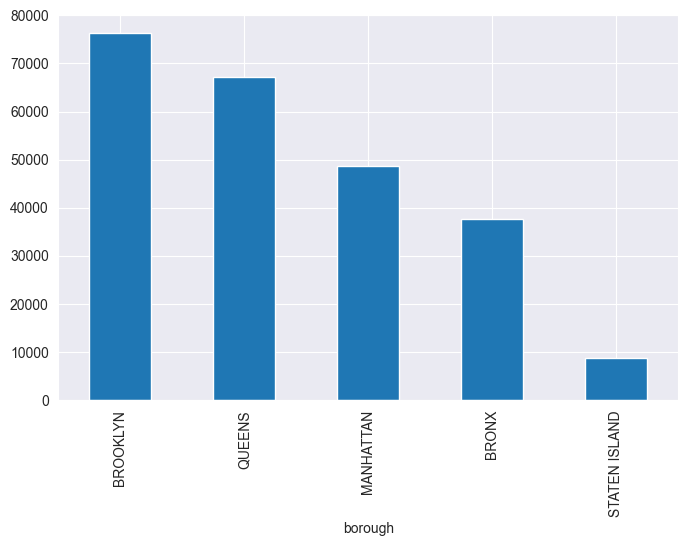

In [5]:
import seaborn as sns
sns.set_style("darkgrid")
print(df['borough'].value_counts())
df['borough'].value_counts().plot(kind='bar', figsize=(8,5))
plt.show()

Total injuries by category:
number_of_pedestrians_injured    13005
number_of_cyclist_injured         5601
number_of_motorist_injured       42475
dtype: int64
Category with most injuried persons is number_of_motorist_injured with count: 42475


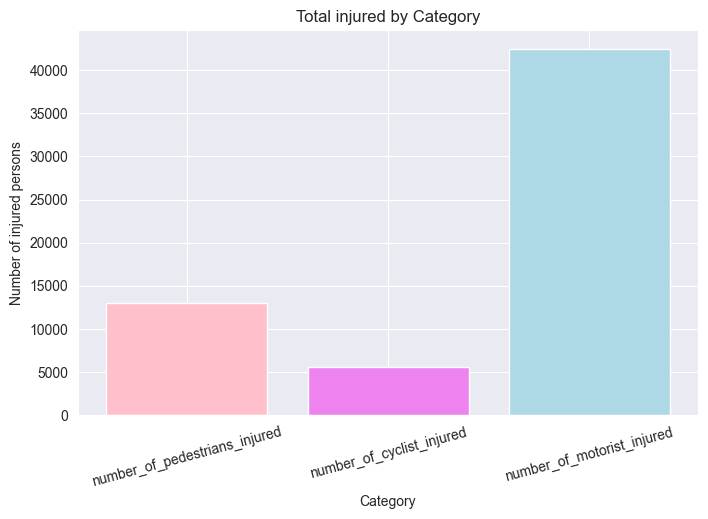

In [6]:
injured_cols = [
    'number_of_pedestrians_injured',
    'number_of_cyclist_injured',
    'number_of_motorist_injured'
]

for column in injured_cols:
    df[column]=df[column].astype(int)

injured_sums = df[injured_cols].sum()
print("Total injuries by category:")
print(injured_sums)

max_injured_category = injured_sums.idxmax()
max_injured_count=injured_sums[max_injured_category]
print("Category with most injuried persons is", max_injured_category, "with count:", max_injured_count)


plt.figure(figsize=(8,5))
plt.bar(injured_sums.index, injured_sums.values, color=['pink', 'violet', 'lightblue'])
plt.title("Total injured by Category")
plt.xlabel("Category")
plt.ylabel("Number of injured persons")
plt.xticks(rotation=15)
plt.show()


Total Deaths by category:
number_of_pedestrians_killed    127
number_of_cyclist_killed         20
number_of_motorist_killed        74
dtype: int64
Category with most dead persons is number_of_pedestrians_killed with count: 127


/var/folders/ql/72ttndnx3rl_77y4q5x_g21c0000gn/T/ipykernel_2953/1848808918.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Deaths', data=killed_df, palette='Reds_r')


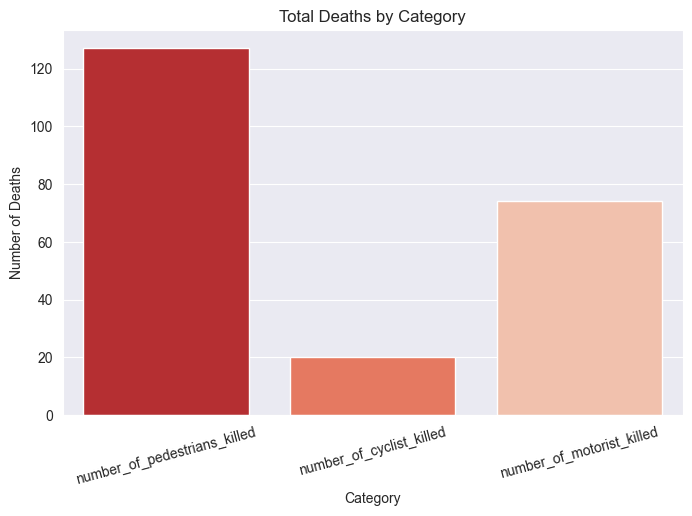

In [7]:
killed_cols = [
    'number_of_pedestrians_killed',
    'number_of_cyclist_killed',
    'number_of_motorist_killed'
]
for column in killed_cols:
    df[column]=df[column].astype(int)

max_dead = df[killed_cols].sum()
print("Total Deaths by category:")
print(max_dead)
max_dead_category = max_dead.idxmax()

max_dead_count = max_dead[max_dead_category]
print("Category with most dead persons is", max_dead_category,"with count:",max_dead_count)

killed_df = max_dead.reset_index()
killed_df.columns = ['Category', 'Deaths']

plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Deaths', data=killed_df, palette='Reds_r')
plt.title("Total Deaths by Category")
plt.xlabel("Category")
plt.ylabel("Number of Deaths")
plt.xticks(rotation=15)
plt.show()

Sedan                                  155882
Station Wagon/Sport Utility Vehicle    124663
PASSENGER VEHICLE                       40623
SPORT UTILITY / STATION WAGON           31219
Taxi                                    16482
Pick-up Truck                           11314
Box Truck                                8786
Bike                                     6343
Bus                                      6008
TAXI                                     5201
Name: count, dtype: int64


/var/folders/ql/72ttndnx3rl_77y4q5x_g21c0000gn/T/ipykernel_2953/2764097412.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_counts.index, y=vehicle_counts.values, palette='viridis')


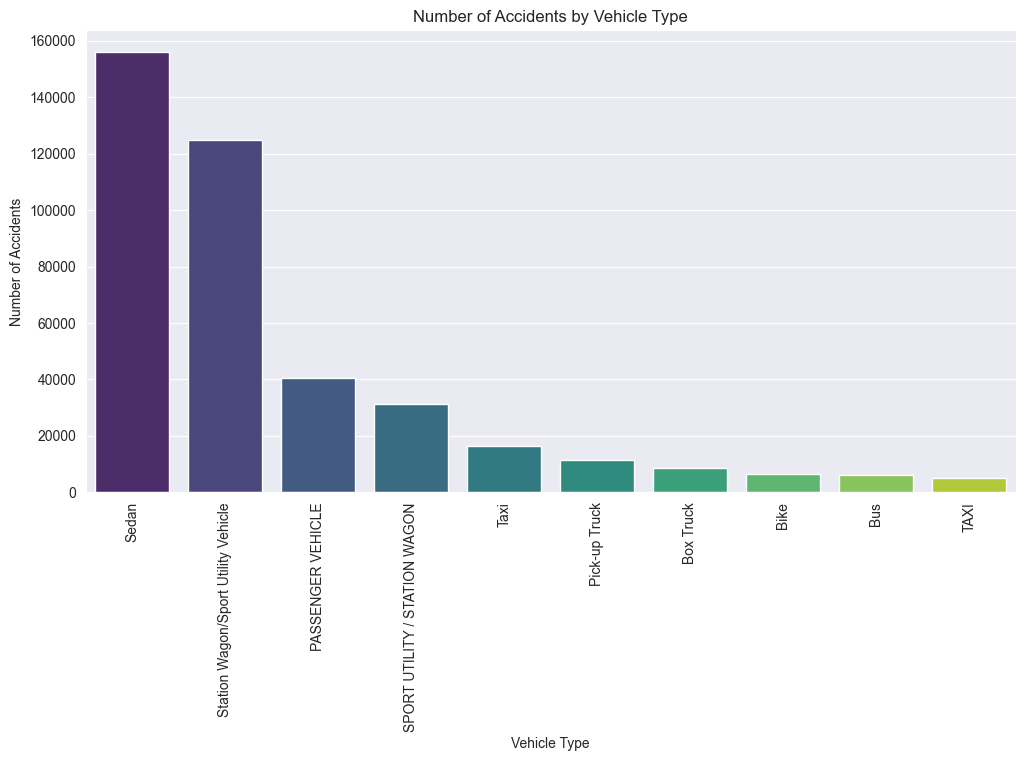

In [8]:
vehicle_cols = ['vehicle_type_code_1', 
                'vehicle_type_code_2',
                'vehicle_type_code_3', 
                'vehicle_type_code_4', 
                'vehicle_type_code_5']
all_vehicles = df[vehicle_cols].stack()
vehicle_counts = all_vehicles.value_counts().head(10)
print(vehicle_counts)

plt.figure(figsize=(12,6))
sns.barplot(x=vehicle_counts.index, y=vehicle_counts.values, palette='viridis')
plt.title("Number of Accidents by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=90)
plt.show()